# FineBio — YOLO26 Fine-tuning for Hand + Object Detection
This notebook converts FineBio COCO annotations to YOLO format, fine-tunes YOLO26, and evaluates against the paper's DINO baseline.

## 1. Install dependencies

In [1]:
!pip install ultralytics mediapipe pycocotools opencv-python matplotlib tqdm -q

## 2. Config — set your paths here

In [4]:
from pathlib import Path

# --- Set these to match your FineBio directory structure ---
FINEBIO_ROOT = Path("/home/nyan/FineBio")  # main FineBio folder

COCO_TRAIN_JSON = (
    FINEBIO_ROOT
    / "01 annotations"
    / "finebio_coco_annotations"
    / "v1_train_joint.json"
)
COCO_VAL_JSON = (
    FINEBIO_ROOT
    / "01 annotations"
    / "finebio_coco_annotations"
    / "v1_valid_joint.json"
)
COCO_TEST_JSON = (
    FINEBIO_ROOT
    / "01 annotations"
    / "finebio_coco_annotations"
    / "v1_test_joint.json"
)

IMAGES_DIR = (
    FINEBIO_ROOT
    / "12 finebio_object_detection_images"
    / "finebio_object_detection_images"
)

YOLO_DATASET_DIR = Path("./finebio_yolo")
RUNS_DIR         = Path("./runs")

YOLO_MODEL       = "yolo26n.pt"
EPOCHS           = 100
IMG_SIZE         = 1280
BATCH_SIZE       = 8
WORKERS          = 8

print("Paths configured.")
print(f"  Train annotations : {COCO_TRAIN_JSON}")
print(f"  Output dataset    : {YOLO_DATASET_DIR}")

Paths configured.
  Train annotations : /home/nyan/FineBio/01 annotations/finebio_coco_annotations/v1_train_joint.json
  Output dataset    : finebio_yolo


## 3. Inspect COCO annotations
Quick sanity check before converting — verify category names and counts.

In [5]:
import json

with open(COCO_TRAIN_JSON) as f:
    coco_train = json.load(f)

categories = coco_train["categories"]
print(f"Total categories  : {len(categories)}")
print(f"Total images      : {len(coco_train['images'])}")
print(f"Total annotations : {len(coco_train['annotations'])}")
print("\nCategories:")
for cat in categories:
    print(f"  [{cat['id']:3d}] {cat['name']}")

Total categories  : 35
Total images      : 1394
Total annotations : 50886

Categories:
  [  1] left_hand
  [  2] right_hand
  [  3] blue_pipette
  [  4] yellow_pipette
  [  5] red_pipette
  [  6] 8_channel_pipette
  [  7] blue_tip
  [  8] yellow_tip
  [  9] red_tip
  [ 10] 8_channel_tip
  [ 11] blue_tip_rack
  [ 12] yellow_tip_rack
  [ 13] red_tip_rack
  [ 14] 8_channel_tip_rack
  [ 15] 50ml_tube
  [ 16] 15ml_tube
  [ 17] micro_tube
  [ 18] 8_tube_stripes
  [ 19] 8_tube_stripes_lid
  [ 20] 50ml_tube_rack
  [ 21] 15ml_tube_rack
  [ 22] micro_tube_rack
  [ 23] 8_tube_stripes_rack
  [ 24] 8_tube_stripes_rack_lid
  [ 25] cell_culture_plate
  [ 26] cell_culture_plate_lid
  [ 27] trash_can
  [ 28] centrifuge
  [ 29] vortex_mixer
  [ 30] magnetic_rack
  [ 31] pcr_machine
  [ 32] tube_with_spin_column
  [ 33] spin_column
  [ 34] tube_without_lid
  [ 35] pen


## 4. COCO → YOLO conversion

In [6]:
import shutil
from tqdm import tqdm

def coco_to_yolo(coco_json_path, images_src_dir, split_name, yolo_root, cat_id_to_idx):
    """
    Convert a single COCO split to YOLO flat directory format.
    Handles nested image directories by searching recursively.
    """
    with open(coco_json_path) as f:
        coco = json.load(f)

    img_dir   = yolo_root / "images" / split_name
    label_dir = yolo_root / "labels" / split_name
    img_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)

    # Build image id -> info map
    id_to_img = {img["id"]: img for img in coco["images"]}

    # Build image id -> annotations map
    id_to_anns = {}
    for ann in coco["annotations"]:
        id_to_anns.setdefault(ann["image_id"], []).append(ann)

    # Index all images in source directory for fast lookup
    print(f"Indexing images in {images_src_dir} ...")
    all_images = {p.name: p for p in Path(images_src_dir).rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]}

    skipped = 0
    for img_id, img_info in tqdm(id_to_img.items(), desc=f"Converting {split_name}"):
        fname     = Path(img_info["file_name"]).name
        src_path  = all_images.get(fname)

        if src_path is None:
            skipped += 1
            continue

        # Copy image
        dst_img = img_dir / fname
        if not dst_img.exists():
            shutil.copy2(src_path, dst_img)

        # Write label file
        W, H = img_info["width"], img_info["height"]
        anns  = id_to_anns.get(img_id, [])
        lines = []
        for ann in anns:
            cat_idx = cat_id_to_idx.get(ann["category_id"])
            if cat_idx is None:
                continue
            x, y, w, h = ann["bbox"]   # COCO: top-left x,y + width, height
            cx = (x + w / 2) / W
            cy = (y + h / 2) / H
            nw = w / W
            nh = h / H
            # Clip to [0,1] to handle any annotation boundary issues
            cx, cy, nw, nh = [max(0.0, min(1.0, v)) for v in [cx, cy, nw, nh]]
            lines.append(f"{cat_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        label_path = label_dir / (Path(fname).stem + ".txt")
        label_path.write_text("\n".join(lines))

    print(f"  Done. Skipped {skipped} images not found in source directory.")


# Build category index (COCO id -> YOLO 0-based index)
with open(COCO_TRAIN_JSON) as f:
    _coco = json.load(f)
categories     = sorted(_coco["categories"], key=lambda c: c["id"])
cat_names      = [c["name"] for c in categories]
cat_id_to_idx  = {c["id"]: i for i, c in enumerate(categories)}
NUM_CLASSES    = len(categories)

print(f"Number of classes: {NUM_CLASSES}")

# Convert all splits
for split, json_path in [("train", COCO_TRAIN_JSON), ("val", COCO_VAL_JSON), ("test", COCO_TEST_JSON)]:
    coco_to_yolo(json_path, IMAGES_DIR, split, YOLO_DATASET_DIR, cat_id_to_idx)

print("\nConversion complete.")

Number of classes: 35
Indexing images in /home/nyan/FineBio/12 finebio_object_detection_images/finebio_object_detection_images ...


Converting train: 100%|██████████| 1394/1394 [00:01<00:00, 968.10it/s]


  Done. Skipped 0 images not found in source directory.
Indexing images in /home/nyan/FineBio/12 finebio_object_detection_images/finebio_object_detection_images ...


Converting val: 100%|██████████| 238/238 [00:00<00:00, 975.71it/s]


  Done. Skipped 0 images not found in source directory.
Indexing images in /home/nyan/FineBio/12 finebio_object_detection_images/finebio_object_detection_images ...


Converting test: 100%|██████████| 303/303 [00:00<00:00, 3459.19it/s]

  Done. Skipped 0 images not found in source directory.

Conversion complete.


## 5. Write YOLO dataset YAML

In [7]:
import yaml

dataset_yaml = {
    "path"  : str(YOLO_DATASET_DIR.resolve()),
    "train" : "images/train",
    "val"   : "images/val",
    "test"  : "images/test",
    "nc"    : NUM_CLASSES,
    "names" : cat_names,
}

yaml_path = YOLO_DATASET_DIR / "finebio.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, allow_unicode=True)

print(f"Dataset YAML written to {yaml_path}")
print(yaml.dump(dataset_yaml, default_flow_style=False))

Dataset YAML written to finebio_yolo/finebio.yaml
names:
- left_hand
- right_hand
- blue_pipette
- yellow_pipette
- red_pipette
- 8_channel_pipette
- blue_tip
- yellow_tip
- red_tip
- 8_channel_tip
- blue_tip_rack
- yellow_tip_rack
- red_tip_rack
- 8_channel_tip_rack
- 50ml_tube
- 15ml_tube
- micro_tube
- 8_tube_stripes
- 8_tube_stripes_lid
- 50ml_tube_rack
- 15ml_tube_rack
- micro_tube_rack
- 8_tube_stripes_rack
- 8_tube_stripes_rack_lid
- cell_culture_plate
- cell_culture_plate_lid
- trash_can
- centrifuge
- vortex_mixer
- magnetic_rack
- pcr_machine
- tube_with_spin_column
- spin_column
- tube_without_lid
- pen
nc: 35
path: /home/nyan/k-project/finebio_yolo
test: images/test
train: images/train
val: images/val



## 6. Verify dataset — visualise a few samples

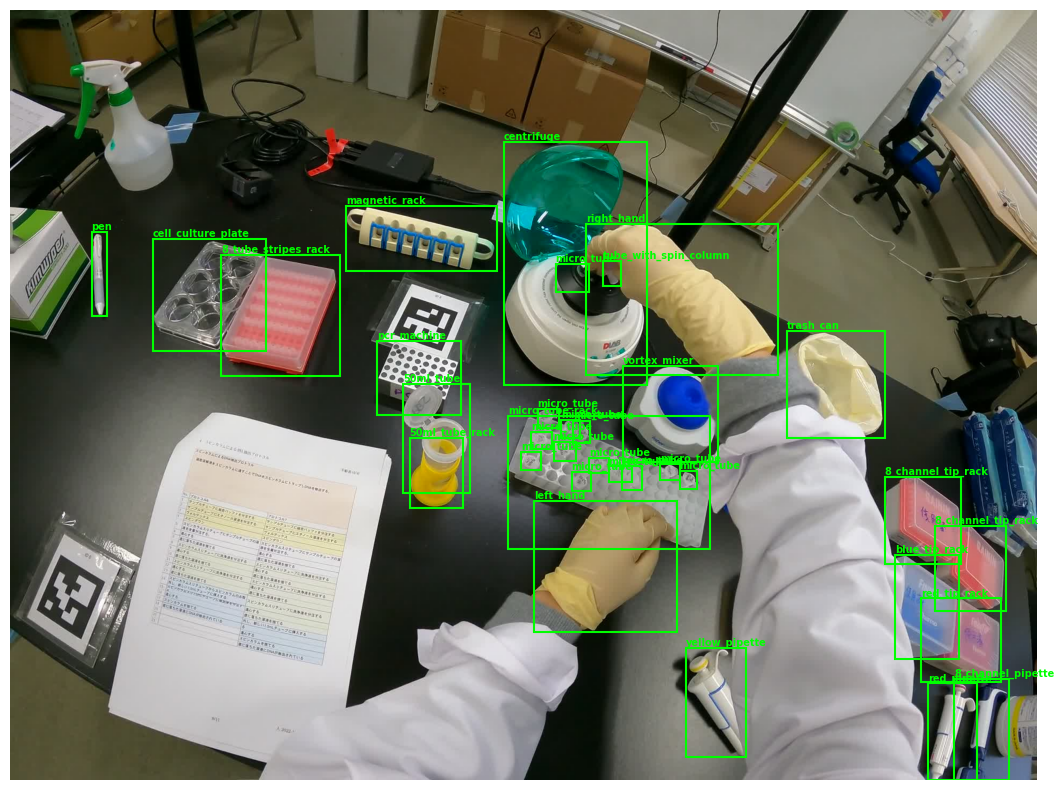

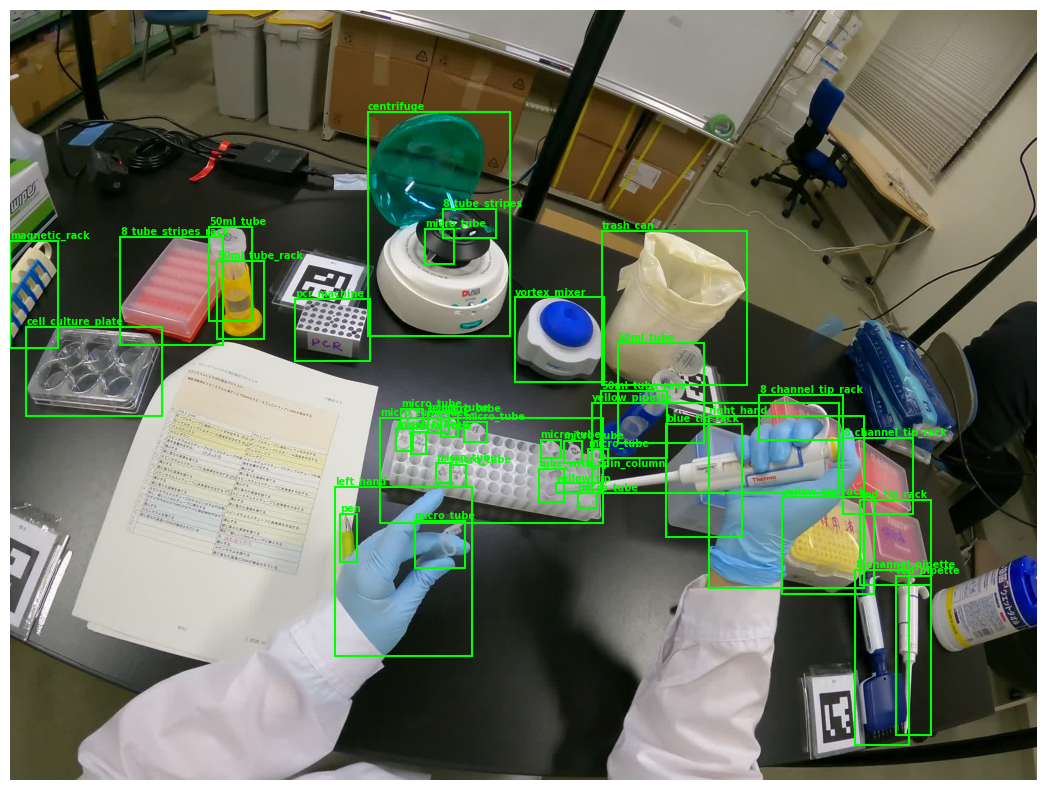

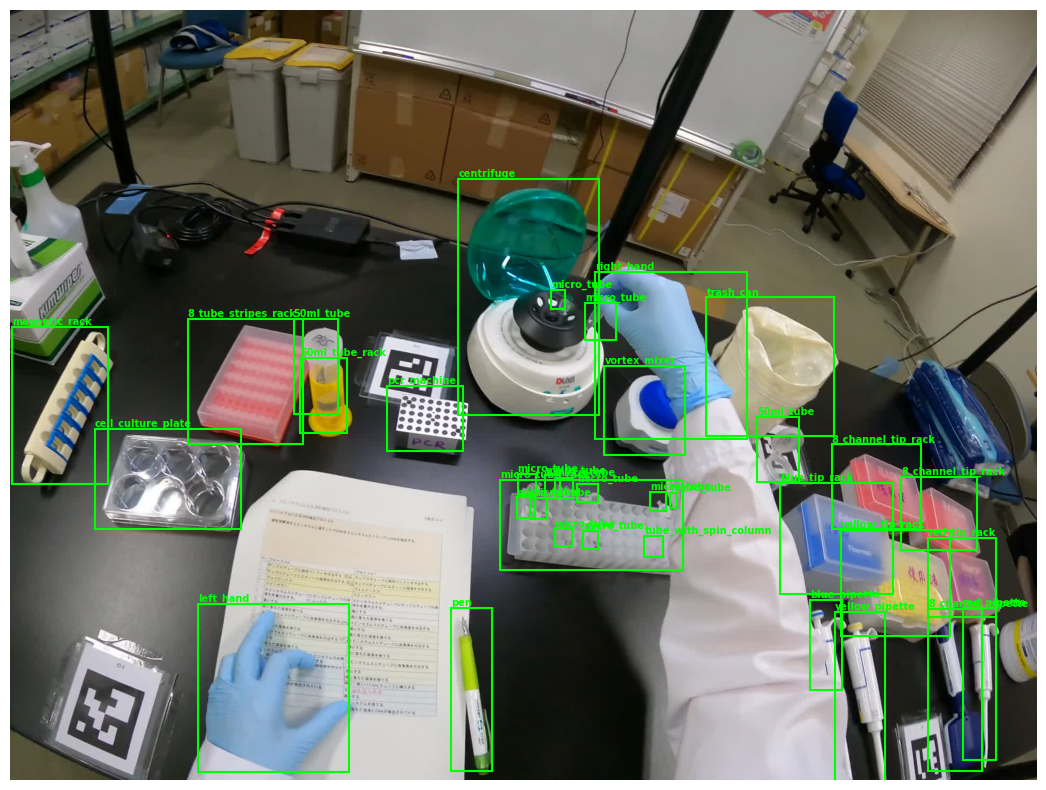

In [8]:
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualise_sample(img_path, label_path, cat_names, n=1):
    img  = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    ax.imshow(img)
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            cls, cx, cy, nw, nh = map(float, line.split())
            x = (cx - nw / 2) * W
            y = (cy - nh / 2) * H
            w = nw * W
            h = nh * H
            rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            ax.text(x, y - 4, cat_names[int(cls)], color="lime", fontsize=7, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

train_imgs = list((YOLO_DATASET_DIR / "images" / "train").glob("*.jpg")) + \
             list((YOLO_DATASET_DIR / "images" / "train").glob("*.png"))

for img_path in random.sample(train_imgs, min(3, len(train_imgs))):
    label_path = YOLO_DATASET_DIR / "labels" / "train" / (img_path.stem + ".txt")
    visualise_sample(img_path, label_path, cat_names)

## 7. Fine-tune YOLO26

In [9]:
from ultralytics import YOLO

model = YOLO(YOLO_MODEL)

results = model.train(
    data        = str(yaml_path),
    epochs      = EPOCHS,
    imgsz       = IMG_SIZE,
    batch       = BATCH_SIZE,
    workers     = WORKERS,
    project     = str(RUNS_DIR),
    name        = "finebio_yolo26",
    # Augmentation — conservative for lab domain (no heavy colour jitter)
    hsv_h       = 0.005,   # minimal hue shift
    hsv_s       = 0.3,
    hsv_v       = 0.3,
    flipud      = 0.0,     # no vertical flip — lab bench has fixed orientation
    fliplr      = 0.3,
    mosaic      = 0.5,
    mixup       = 0.1,
    # Training
    optimizer   = "AdamW",
    lr0         = 1e-3,
    lrf         = 0.01,
    warmup_epochs = 3,
    cos_lr      = True,
    patience    = 20,      # early stopping
    save_period = 10,
    device      = 0,       # GPU 0
    verbose     = True,
)

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15843MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=finebio_yolo/finebio.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.3, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.005, hsv_s=0.3, hsv_v=0.3, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=fine

## 8. Evaluate on test set
Compare against the paper's reported DINO baseline numbers.

In [12]:
from ultralytics import YOLO

# Load best checkpoint
best_weights = RUNS_DIR / "detect" / "runs" / "finebio_yolo26" / "yolo26n_joint3" / "weights" / "best.pt"
print("Using weights:", best_weights)
model_eval = YOLO(str(best_weights))

metrics = model_eval.val(
    data   = str(yaml_path),
    split  = "test",
    imgsz  = IMG_SIZE,
    device = 0,
    verbose= True,
)

print("\n--- Results vs Paper Baseline (DINO) ---")
print(f"mAP50       : {metrics.box.map50:.4f}")
print(f"mAP50-95    : {metrics.box.map:.4f}")
print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")
print("\nPaper DINO AP (reference): check Table X in FineBio paper")

Using weights: runs/detect/runs/finebio_yolo26/yolo26n_joint3/weights/best.pt
Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15843MiB)
YOLO26n summary (fused): 122 layers, 2,381,661 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5312.4±1530.1 MB/s, size: 141.1 KB)
val: Scanning /home/nyan/k-project/finebio_yolo/labels/test... 303 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 303/303 3.1Kit/s 0.1s
val: New cache created: /home/nyan/k-project/finebio_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.2it/s 4.6s0.2s
                   all        303      11795      0.407      0.356      0.364       0.26
             left_hand        301        301      0.491      0.621      0.571      0.422
            right_hand        296        296      0.533      0.564      0.544      0.374
          blue_pipette        260       

## 9. Per-class AP breakdown

                  class     AP50
           vortex_mixer 0.852763
              trash_can 0.840826
             centrifuge 0.801093
    8_tube_stripes_rack 0.792789
            pcr_machine 0.773433
        micro_tube_rack 0.745708
     8_channel_tip_rack 0.725573
        yellow_tip_rack 0.707589
          blue_tip_rack 0.671289
          magnetic_rack 0.658901
           red_tip_rack 0.626155
              left_hand 0.571118
     cell_culture_plate 0.547612
             right_hand 0.543854
8_tube_stripes_rack_lid 0.543038
              50ml_tube 0.542878
         50ml_tube_rack 0.437542
             micro_tube 0.268691
                    pen 0.216289
         8_tube_stripes 0.180210
            red_pipette 0.179109
      8_channel_pipette 0.178269
         15ml_tube_rack 0.112150
         yellow_pipette 0.086222
           blue_pipette 0.060209
              15ml_tube 0.031149
 cell_culture_plate_lid 0.025420
  tube_with_spin_column 0.008904
     8_tube_stripes_lid 0.006540
          

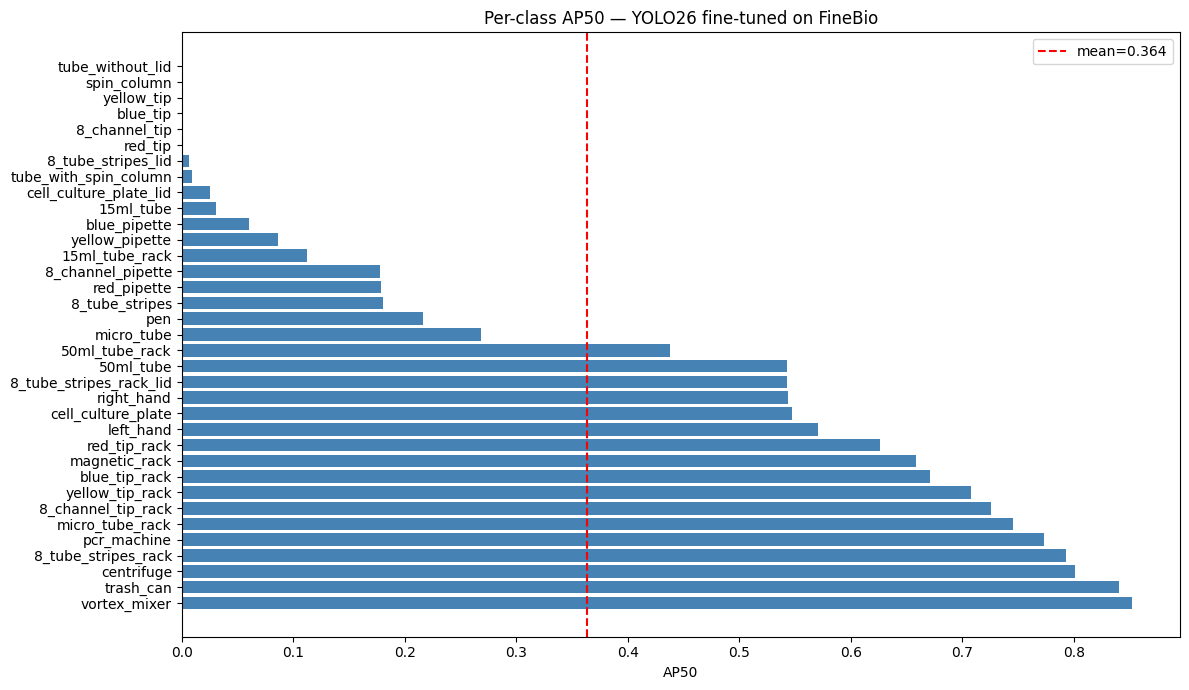

In [13]:
import pandas as pd

per_class_ap = metrics.box.ap_class_index
ap50_vals    = metrics.box.ap50

df = pd.DataFrame({
    "class"  : [cat_names[i] for i in per_class_ap],
    "AP50"   : ap50_vals,
}).sort_values("AP50", ascending=False)

print(df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df["class"], df["AP50"], color="steelblue")
ax.set_xlabel("AP50")
ax.set_title("Per-class AP50 — YOLO26 fine-tuned on FineBio")
ax.axvline(df["AP50"].mean(), color="red", linestyle="--", label=f"mean={df['AP50'].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

## 10. MediaPipe hand keypoints — run alongside YOLO
Extracts 21 hand landmarks per frame for use in contact detection downstream.

In [ ]:
import mediapipe as mp
from mediapipe.python.solutions import hands as mp_hands
from mediapipe.python.solutions import drawing_utils as mp_drawing
import cv2
import json
from pathlib import Path
from tqdm import tqdm

def extract_hand_keypoints(image_paths, output_json_path, max_num_hands=2):
    """
    Run MediaPipe Hands on a list of images.
    Saves {filename: {"left": [...21 (x,y,z)...], "right": [...]}} to JSON.
    """
    results_dict = {}
    with mp_hands.Hands(
        static_image_mode     = True,
        max_num_hands         = max_num_hands,
        min_detection_confidence = 0.5,
    ) as hands:
        for img_path in tqdm(image_paths, desc="MediaPipe hand keypoints"):
            img   = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            res   = hands.process(img)
            entry = {"left": None, "right": None}
            if res.multi_hand_landmarks and res.multi_handedness:
                for lm, hd in zip(res.multi_hand_landmarks, res.multi_handedness):
                    side = hd.classification[0].label.lower()  # "left" or "right"
                    entry[side] = [[lm.landmark[i].x, lm.landmark[i].y, lm.landmark[i].z]
                                   for i in range(21)]
            results_dict[img_path.name] = entry

    with open(output_json_path, "w") as f:
        json.dump(results_dict, f)
    print(f"Saved keypoints for {len(results_dict)} images to {output_json_path}")


# Run on test set as a demo — run on train/val similarly
test_imgs = list((YOLO_DATASET_DIR / "images" / "test").glob("*.jpg")) + \
            list((YOLO_DATASET_DIR / "images" / "test").glob("*.png"))

extract_hand_keypoints(
    test_imgs,
    output_json_path = YOLO_DATASET_DIR / "hand_keypoints_test.json",
)

I0000 00:00:1773388943.675085 1193520 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773388943.746719 1205336 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.86.10), renderer: NVIDIA GeForce RTX 5080/PCIe/SSE2
MediaPipe hand keypoints:   0%|          | 0/303 [00:00<?, ?it/s]INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773388943.757228 1205309 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773388943.775652 1205334 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/home/nyan/miniconda3/envs/k-pro/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be remo

Saved keypoints for 303 images to finebio_yolo/hand_keypoints_test.json


## 11. Combined inference — YOLO26 + MediaPipe on a single frame

I0000 00:00:1773388985.919030 1193520 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773388985.951271 1205527 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.86.10), renderer: NVIDIA GeForce RTX 5080/PCIe/SSE2
W0000 00:00:1773388985.956541 1205499 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773388985.971972 1205498 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


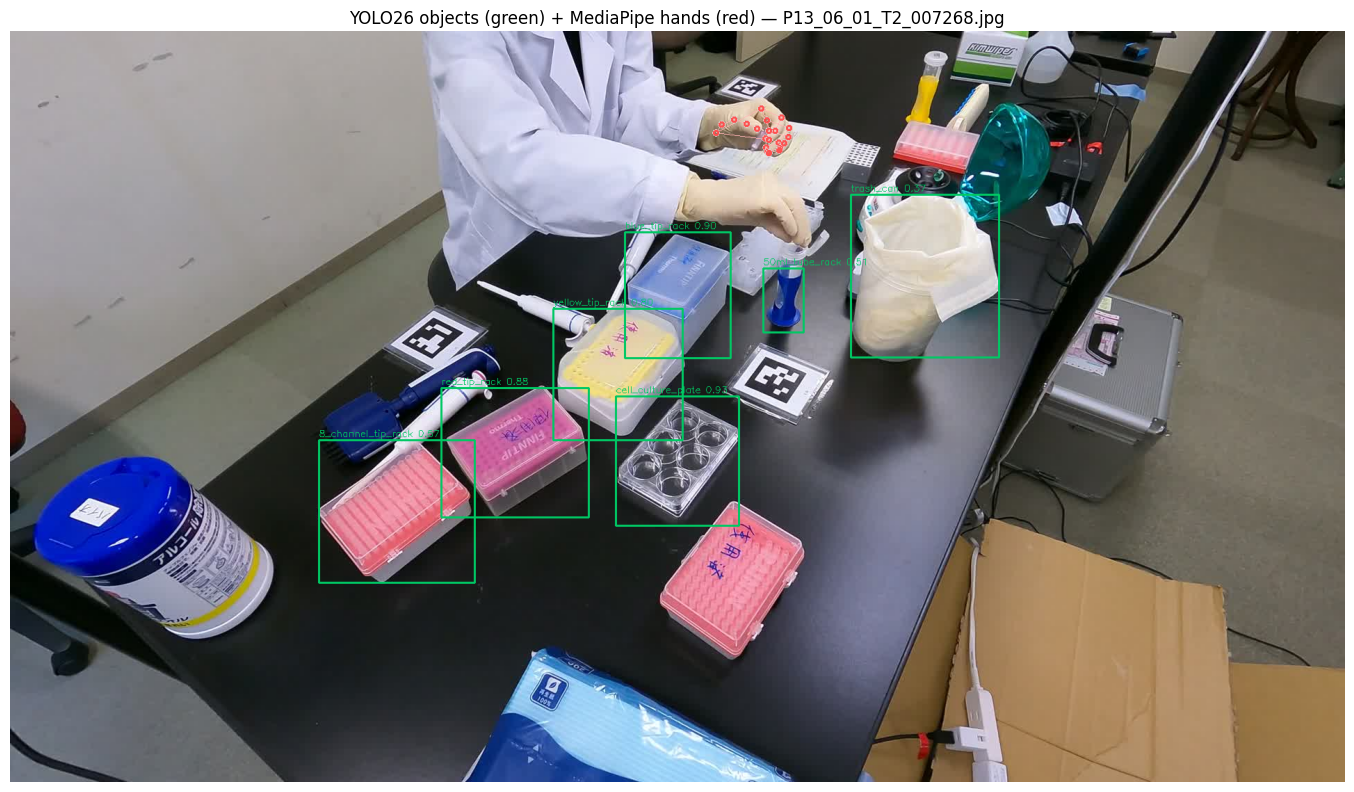

In [ ]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.python.solutions import hands as mp_hands
from mediapipe.python.solutions import drawing_utils as mp_drawing
import numpy as np
import random

def run_combined(img_path, yolo_model, conf=0.3):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W    = img_rgb.shape[:2]
    canvas  = img_rgb.copy()

    # YOLO26 detections
    yolo_res = yolo_model(img_path, conf=conf, verbose=False)[0]
    for box in yolo_res.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls  = int(box.cls[0])
        conf_ = float(box.conf[0])
        label = f"{cat_names[cls]} {conf_:.2f}"
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 200, 100), 2)
        cv2.putText(canvas, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 100), 1)

    # MediaPipe hand keypoints
    with mp_hands.Hands(static_image_mode=True, max_num_hands=2,
                        min_detection_confidence=0.5) as hands:
        res = hands.process(img_rgb)
        if res.multi_hand_landmarks:
            for lm in res.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    canvas, lm, mp_hands.HAND_CONNECTIONS,
                    mp_drawing.DrawingSpec(color=(255, 80, 80), thickness=2, circle_radius=3),
                    mp_drawing.DrawingSpec(color=(255, 180, 180), thickness=1),
                )

    plt.figure(figsize=(14, 8))
    plt.imshow(canvas)
    plt.axis("off")
    plt.title(f"YOLO26 objects (green) + MediaPipe hands (red) — {Path(img_path).name}")
    plt.tight_layout()
    plt.show()


# Run on a random test image
sample = random.choice(test_imgs)
run_combined(sample, model_eval, conf=0.3)

## 12. Next steps
Once detection looks solid, the next stage is:
- **Multi-view triangulation** — use calibrated camera params to lift 2D bboxes to approximate 3D positions
- **Scene graph construction** — persistent object state tracking across frames
- **Contact detection** — use MediaPipe fingertip proximity to YOLO bboxes to detect hand-object contact events
- **Graph transition detection** — atomic operations as detected state changes in the scene graph